In [23]:
import pandas as pd
import json
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 7)
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.labelsize'] = 12

## DATA LOADING & CLEANING

In [24]:
baseline_log_path = 'data/history/baseline_architecture_log.json'
graph_log_path = 'data/history/graph_architecture_log.json'
log_files = [baseline_log_path, graph_log_path]

all_data = []
for log_file in log_files:
    if os.path.exists(log_file):
        with open(log_file, 'r') as f:
            try:
                data = json.load(f)
                if isinstance(data, list):
                    all_data.extend(data)
                else:
                    print(f"Warning: Log file {log_file} does not contain a JSON list.")
            except json.JSONDecodeError:
                print(f"Error: Could not decode JSON from {log_file}.")
    else:
        print(f"Error: Log file not found at {log_file}.")

if not all_data:
    print("CRITICAL ERROR: No data was loaded. Please ensure the log files exist and are valid JSON. Aborting analysis.")
else:
    df = pd.DataFrame(all_data)
    
    # Convert data types, coercing errors to NaN
    numeric_cols = ['latency_ms', 'total_tokens', 'critic_rejections']
    for col in numeric_cols:
        df[col] = pd.to_numeric(df[col], errors='coerce')

    # Safely extract 'used_tool' boolean column
    def check_for_tool_use(output_dict):
        """Robustly checks for a non-null 'pending_action' key."""
        if isinstance(output_dict, dict):
            # The presence of a non-None value in 'pending_action' indicates a tool was used.
            return output_dict.get('pending_action') is not None
        return False

    df['used_tool'] = df['final_output'].apply(check_for_tool_use)
    
    print(f"Successfully loaded and processed {len(df)} total turns.")
    print("DataFrame head:")
    print(df.head())

Successfully loaded and processed 30 total turns.
DataFrame head:
                 timestamp_utc                  architecture  latency_ms  \
0  2026-03-15T08:36:44.013919Z                      baseline       38484   
1  2026-03-15T08:40:51.555504Z                      baseline      244830   
2  2026-03-15T08:43:07.479969Z  progressive_disclosure_graph       47027   
3  2026-03-15T09:19:08.990083Z  progressive_disclosure_graph       53681   
4  2026-03-15T09:20:17.114088Z  progressive_disclosure_graph       37539   

   total_tokens            route_taken  critic_rejections  \
0             0  N/A - Linear Pipeline                  0   
1             0  N/A - Linear Pipeline                  0   
2             0       combat_mechanics                  0   
3             0       combat_mechanics                  0   
4             0            system_roll                  0   

                                       player_intent  \
0      Draw my sword and dare anyone to challenge me  

## EVALUATION 1: OVERALL ARCHITECTURE PERFORMANCE

                              total_turns  avg_latency_ms  median_latency_ms  \
architecture                                                                   
baseline                                2       141657.00           141657.0   
progressive_disclosure_graph           28        61658.57            62231.5   

                             tool_utilization_rate  
architecture                                        
baseline                                     50.0%  
progressive_disclosure_graph                 25.0%  


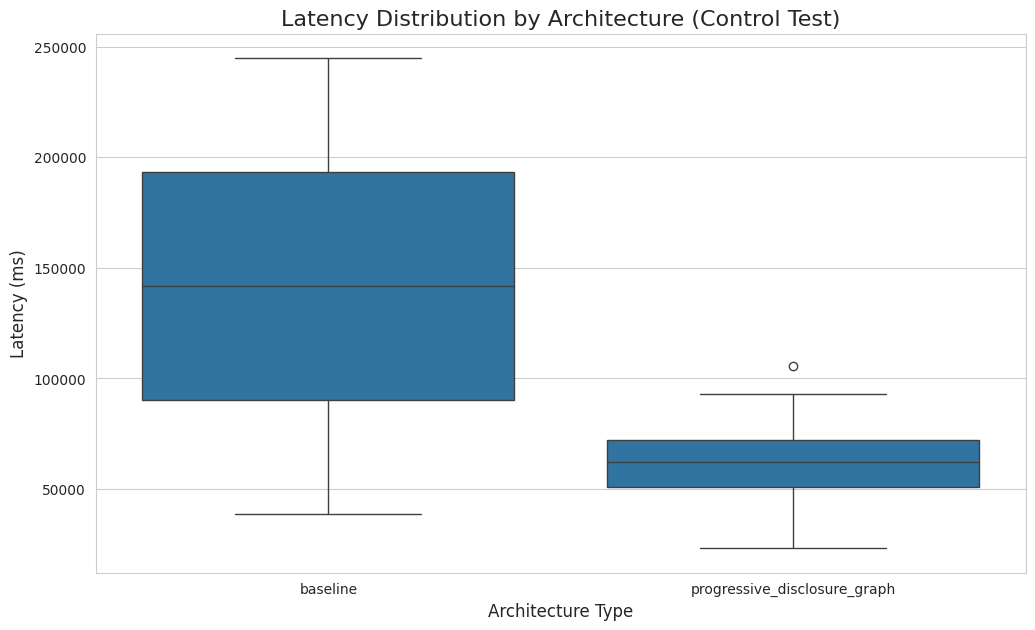

In [25]:
# Group by architecture and calculate key metrics
overall_performance = df.groupby('architecture').agg(
    total_turns=('architecture', 'size'),
    avg_latency_ms=('latency_ms', 'mean'),
    median_latency_ms=('latency_ms', 'median'),
    tool_utilization_rate=('used_tool', 'mean')
).round(2)

# Format tool utilization as a percentage
overall_performance['tool_utilization_rate'] = (overall_performance['tool_utilization_rate'] * 100).map('{:.1f}%'.format)

print(overall_performance)

# Generate Boxplot for Latency
plt.figure()
sns.boxplot(x='architecture', y='latency_ms', data=df)
plt.title('Latency Distribution by Architecture (Control Test)')
plt.xlabel('Architecture Type')
plt.ylabel('Latency (ms)')
plt.show()

## EVALUATION 2: SEMANTIC ROUTER EFFICIENCY (GRAPH ONLY)

                  turn_count  avg_latency_ms
route_taken                                 
social_lore                6        69947.50
system_roll                7        63751.43
combat_mechanics          15        57366.33


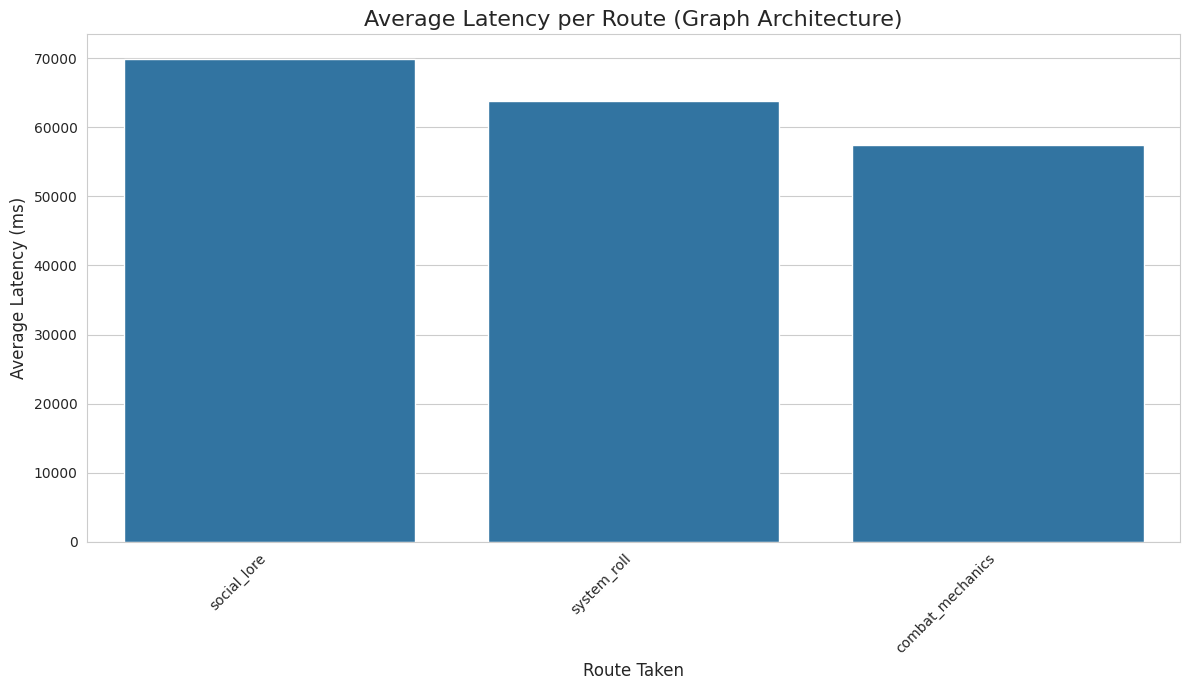

In [26]:
graph_df = df[df['architecture'] == 'progressive_disclosure_graph'].copy()
    
if graph_df.empty:
    print("Warning: No data found for 'progressive_disclosure_graph'. Skipping this evaluation.")
else:
    # Group by the route taken and calculate metrics
    router_efficiency = graph_df.groupby('route_taken').agg(
        turn_count=('route_taken', 'size'),
        avg_latency_ms=('latency_ms', 'mean')
    ).sort_values(by='avg_latency_ms', ascending=False).round(2)
    
    print(router_efficiency)
    
    # Generate Bar Chart for Router Latency
    plt.figure()
    sns.barplot(x=router_efficiency.index, y=router_efficiency['avg_latency_ms'])
    plt.title('Average Latency per Route (Graph Architecture)')
    plt.xlabel('Route Taken')
    plt.ylabel('Average Latency (ms)')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
    

## EVALUATION 3: THE COST OF REFLECTION (GRAPH ONLY)

In [27]:
if graph_df.empty:
    print("Warning: No data found for 'progressive_disclosure_graph'. Skipping this evaluation.")
else:
    # Create a new column to categorize turns with and without self-correction
    graph_df['had_rejections'] = graph_df['critic_rejections'] > 0
    
    # Group by this new category and calculate average latency
    reflection_cost = graph_df.groupby('had_rejections')['latency_ms'].mean().reset_index()
    reflection_cost['had_rejections'] = reflection_cost['had_rejections'].map({False: 'No Rejections', True: 'With Rejections'})
    
    print("Average Latency with vs. without Critic Rejections:")
    print(reflection_cost.round(2))
    
    if len(reflection_cost) > 1:
        latency_no_rejection = reflection_cost.loc[reflection_cost['had_rejections'] == 'No Rejections', 'latency_ms'].iloc[0]
        latency_with_rejection = reflection_cost.loc[reflection_cost['had_rejections'] == 'With Rejections', 'latency_ms'].iloc[0]
        penalty = latency_with_rejection - latency_no_rejection
        print(f"The calculated time penalty for a ReAct loop is: {penalty:.2f} ms")
    else:
        print("Could not calculate penalty: only one category (with/without rejections) was present in the data.")


Average Latency with vs. without Critic Rejections:
    had_rejections  latency_ms
0    No Rejections    61246.63
1  With Rejections    72781.00
The calculated time penalty for a ReAct loop is: 11534.37 ms


## EVALUATION 4: INSTRUCTION ADHERENCE & AGENTIC BEHAVIOR

In [28]:
# Side-by-side comparison of tool utilization rate
tool_adherence_df = overall_performance[['total_turns', 'tool_utilization_rate']].copy()
print("Side-by-Side Tool Utilization Rate:")
print(tool_adherence_df)

# Qualitative analysis: Show a sample of intents and their outcomes
print("Qualitative Sample: Mapping Player Intent to Route and Tool Use")
sample_columns = ['player_intent', 'architecture', 'route_taken', 'used_tool']

# Avoid sampling if data is too small to prevent errors
baseline_sample_size = min(5, len(df[df['architecture'] == 'baseline']))
graph_sample_size = min(5, len(df[df['architecture'] == 'progressive_disclosure_graph']))

if baseline_sample_size > 0:
    print("--- Baseline Samples ---")
    print(df[df['architecture'] == 'baseline'][sample_columns].sample(baseline_sample_size))

if graph_sample_size > 0:
    print("--- Graph Samples ---")
    print(df[df['architecture'] == 'progressive_disclosure_graph'][sample_columns].sample(graph_sample_size))


Side-by-Side Tool Utilization Rate:
                              total_turns tool_utilization_rate
architecture                                                   
baseline                                2                 50.0%
progressive_disclosure_graph           28                 25.0%
Qualitative Sample: Mapping Player Intent to Route and Tool Use
--- Baseline Samples ---
                                       player_intent architecture  \
0      Draw my sword and dare anyone to challenge me     baseline   
1  [SYSTEM: ROLL_RESOLUTION | INTENT: Draw my swo...     baseline   

             route_taken  used_tool  
0  N/A - Linear Pipeline       True  
1  N/A - Linear Pipeline      False  
--- Graph Samples ---
                                        player_intent  \
29                  Ready myself to dodge his attacks   
5       Draw my sword and dare anyone to challenge me   
17  "Should you best me, you may take my wife, my ...   
11      Draw my sword and dare anyone to challe